In [20]:
from discretize import TreeMesh
from discretize.utils import active_from_xyz
import matplotlib.pyplot as plt
import numpy as np
import simpeg.potential_fields as pf
from simpeg import (
    data_misfit,
    directives,
    inverse_problem,
    inversion,
    maps,
    optimization,
    regularization,
    utils,
)
from simpeg.utils import io_utils, plot2Ddata

# Common Python functionality
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

## Setup

## 1. import mesh and model

In [21]:
mesh_file = io_utils.download(
    "https://storage.googleapis.com/simpeg/pgi_tutorial_assets/mesh_tutorial.ubc"
)
mesh = TreeMesh.read_UBC(mesh_file)

file already exists, new file is called c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\mesh_tutorial.ubc
   saved to: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\mesh_tutorial.ubc
Download completed!


In [22]:
true_geology_file = io_utils.download(
    "https://storage.googleapis.com/simpeg/pgi_tutorial_assets/geology_true.mod"
)
true_geology = mesh.read_model_UBC(true_geology_file)

file already exists, new file is called c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\geology_true.mod
   saved to: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\geology_true.mod
Download completed!


## 2. plot mesh and model

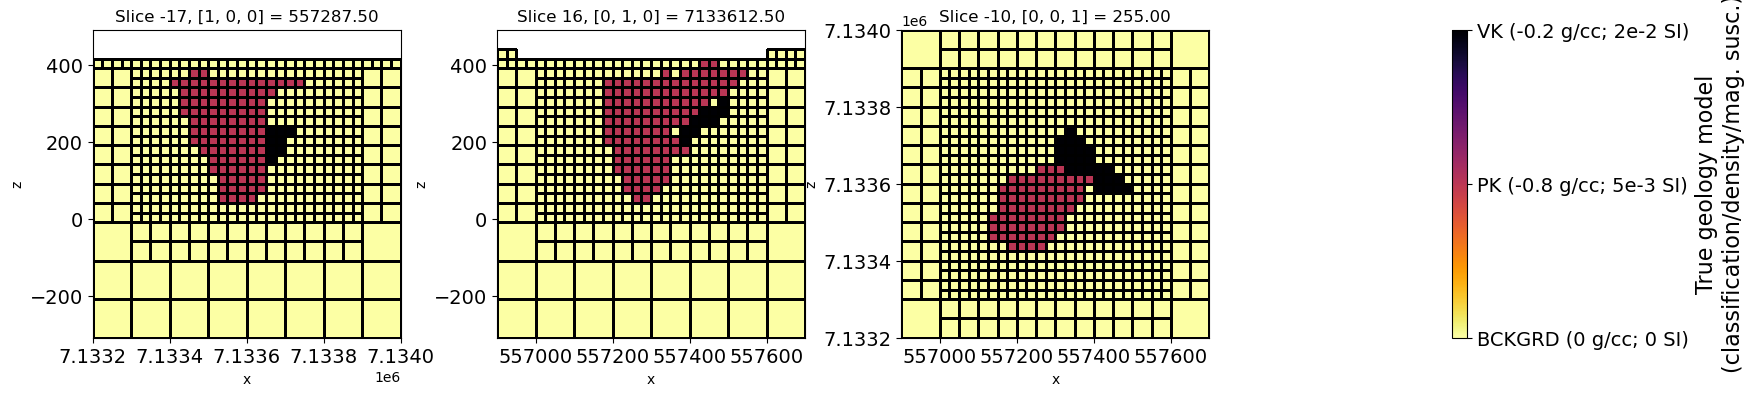

In [23]:
# Plot true geology model
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ticksize, labelsize = 14, 16
for _, axx in enumerate(ax):
    axx.set_aspect(1)
    axx.tick_params(labelsize=ticksize)
mesh.plot_slice(
    true_geology,
    normal="X",
    ax=ax[0],
    ind=-17,
    clim=[0, 2],
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
mesh.plot_slice(
    true_geology,
    normal="Y",
    ax=ax[1],
    clim=[0, 2],
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
geoplot = mesh.plot_slice(
    true_geology,
    normal="Z",
    ax=ax[2],
    clim=[0, 2],
    ind=-10,
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
geocb = plt.colorbar(geoplot[0], cax=ax[3], ticks=[0, 1, 2])
geocb.set_label(
    "True geology model\n(classification/density/mag. susc.)", fontsize=labelsize
)
geocb.set_ticklabels(
    ["BCKGRD (0 g/cc; 0 SI)", "PK (-0.8 g/cc; 5e-3 SI)", "VK (-0.2 g/cc; 2e-2 SI)"]
)
geocb.ax.tick_params(labelsize=ticksize)
ax[3].set_aspect(10)
plt.show()


C:\Users\30562\AppData\Local\Temp\ipykernel_52860\1526483969.py:55: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  p.show()


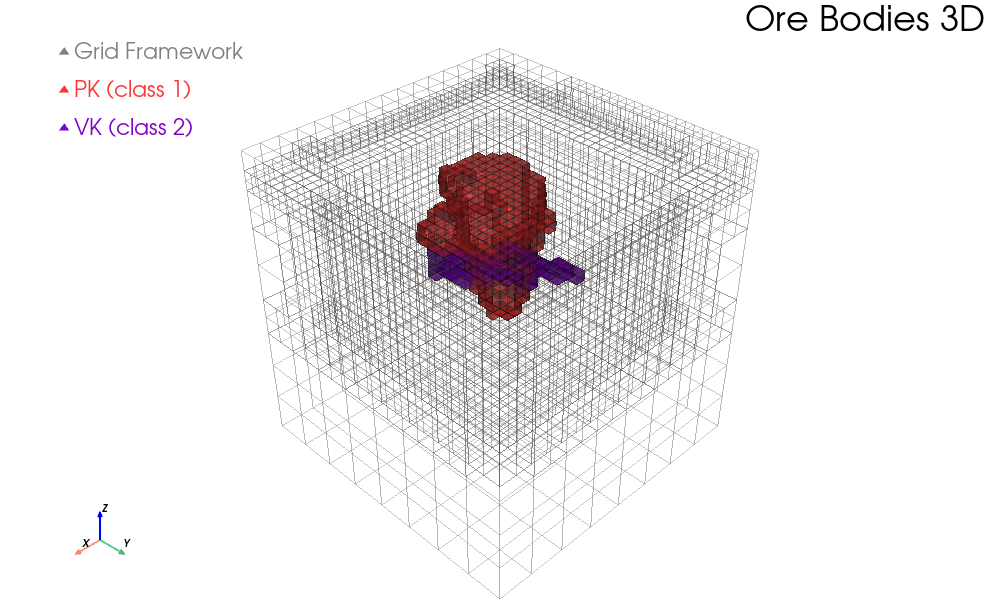

In [24]:
# 3D 可视化 - 网格线框 + 离散颜色 (pyvista)
import pyvista as pv

# 只提取矿体单元 (class 1: PK, class 2: VK，不显示背景 class 0)
mask_orebody = (true_geology > 0)  # True for ore bodies
cell_ids = np.where(mask_orebody)[0]

# 从 mesh 转换为 UnstructuredGrid
ug = mesh.to_vtk()  # TreeMesh 转 VTK

# 提取矿体单元及其对应的类别值
ug_orebody = ug.extract_cells(cell_ids)
geology_orebody = true_geology[cell_ids]

# 将类别数据附加到提取的网格
ug_orebody["geology"] = geology_orebody

# 离散颜色映射 (PK=1: 红色, VK=2: 紫色)
geology_colors = {
    1: [1.0, 0.2, 0.2],  # PK - 红色
    2: [0.5, 0.0, 0.8],  # VK - 紫色
}

p = pv.Plotter(window_size=(1000, 600))
p.background_color = "white"  # 白色背景

# 添加整个网格的边框作为参考框架（半透明灰色）
p.add_mesh(
    ug,
    style="wireframe",
    color="gray",
    line_width=0.1,
    opacity=0.2,
    label="Grid Framework",
)

# 为两个矿体分别添加网格线框
for ore_class, color in geology_colors.items():
    mask = geology_orebody == ore_class
    cell_subset = ug_orebody.extract_cells(np.where(mask)[0])
    label = f"PK (class {ore_class})" if ore_class == 1 else f"VK (class {ore_class})"
    p.add_mesh(
        cell_subset,
        color=color,
        show_edges=True,
        edge_color="black",
        line_width=0.5,
        opacity=0.7,
        label=label,
    )

p.add_axes(line_width=2)
p.add_legend(loc="upper left")
p.add_text("Ore Bodies 3D 网格模型", position="upper_right", font_size=14)
p.show()

In [25]:
# 导出 VTK 文件
import os

# 创建输出目录
output_dir = "vtk_output"
os.makedirs(output_dir, exist_ok=True)

# 导出完整网格（带地质分类）
mesh_file_path = os.path.join(output_dir, "geological_mesh_full.vtk")
ug.save(mesh_file_path)
print(f"✓ 完整网格已保存: {mesh_file_path}")

# 导出矿体网格（仅矿体）
orebody_file_path = os.path.join(output_dir, "ore_bodies.vtk")
ug_orebody.save(orebody_file_path)
print(f"✓ 矿体网格已保存: {orebody_file_path}")

print(f"\n所有文件保存在: {os.path.abspath(output_dir)}")
print(f"可用 ParaView 或其他 VTK 查看器打开这些文件")

✓ 完整网格已保存: vtk_output\geological_mesh_full.vtk
✓ 矿体网格已保存: vtk_output\ore_bodies.vtk

所有文件保存在: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\vtk_output
可用 ParaView 或其他 VTK 查看器打开这些文件


## 3. import gravity data

In [26]:
data_grav_file = io_utils.download(
    "https://storage.googleapis.com/simpeg/pgi_tutorial_assets/gravity_data.obs"
)
data_grav = io_utils.read_grav3d_ubc(data_grav_file)

file already exists, new file is called c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\gravity_data.obs
   saved to: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\gravity_data.obs
Download completed!


C:\Users\30562\AppData\Local\Temp\ipykernel_52860\1136830129.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


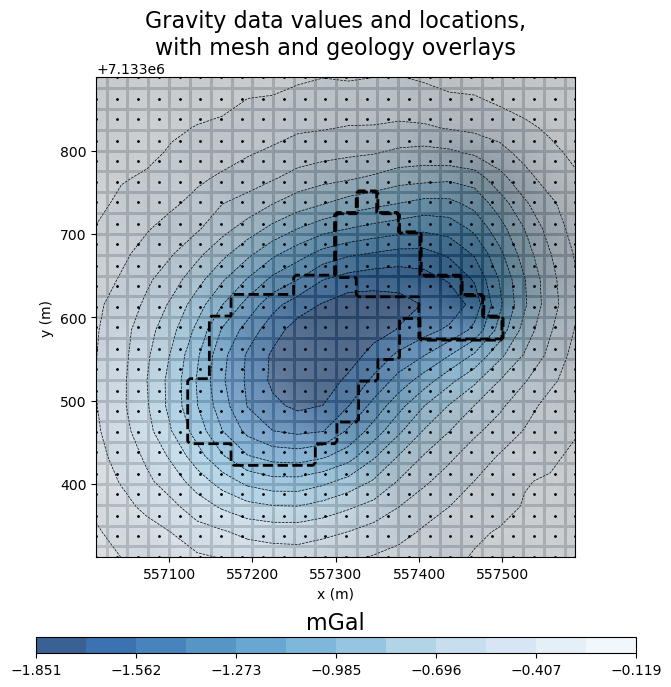

In [27]:
# plot gravity data and mesh
fig = plt.figure(figsize=(10, 8))

# main axis
ax = fig.add_axes([0.1, 0.2, 0.8, 0.6])

mesh.plot_slice(
    np.ones(mesh.nC),
    normal="Z",
    ind=int(-10),
    grid=True,
    pcolor_opts={"cmap": "Greys"},
    ax=ax,
)

mm = utils.plot2Ddata(
    data_grav.survey.receiver_locations,
    -data_grav.dobs,
    ax=ax,
    level=True,
    nx=20,
    ny=20,
    dataloc=True,
    ncontour=12,
    shade=True,
    contourOpts={"cmap": "Blues_r", "alpha": 0.8},
    levelOpts={"colors": "k", "linewidths": 0.5, "linestyles": "dashed"},
)

ax.set_aspect(1)
ax.set_title(
    "Gravity data values and locations,\nwith mesh and geology overlays",
    fontsize=16,
)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.set_xlim(
    [
        data_grav.survey.receiver_locations[:, 0].min(),
        data_grav.survey.receiver_locations[:, 0].max(),
    ],
)
ax.set_ylim(
    [
        data_grav.survey.receiver_locations[:, 1].min(),
        data_grav.survey.receiver_locations[:, 1].max(),
    ],
)

# overlay true geology model for comparison
indz = -10
indslicezplot = mesh.gridCC[:, 2] == mesh.cell_centers_z[indz]

utils.plot2Ddata(
    mesh.gridCC[indslicezplot][:, [0, 1]],
    true_geology[indslicezplot],
    nx=200,
    ny=200,
    contourOpts={"alpha": 0},
    clim=[0, 2],
    ax=ax,
    level=True,
    ncontour=2,
    levelOpts={"colors": "k", "linewidths": 2, "linestyles": "--"},
    method="nearest",
)

# colorbar axis
cax = fig.add_axes([0.2, 0.08, 0.6, 0.02])
plt.colorbar(mm[0], cax=cax, orientation="horizontal")
cax.set_title("mGal", fontsize=16)

plt.tight_layout()
plt.show()

## 4. import topography

In [28]:
# Load Topo
topo_file = io_utils.download(
    "https://storage.googleapis.com/simpeg/pgi_tutorial_assets/CDED_Lake_warp.xyz"
)
topo = np.genfromtxt(topo_file, skip_header=1)

file already exists, new file is called c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\CDED_Lake_warp.xyz
   saved to: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model\CDED_Lake_warp.xyz
Download completed!


In [29]:
# find the active cells
active_cells = active_from_xyz(mesh, topo, "CC")

# Create active map to go from reduced set to full
plotting_Map = maps.InjectActiveCells(mesh, active_cells, np.nan)
n_active = int(active_cells.sum())

# Identity map for density-only inversion
model_Map = maps.IdentityMap(nP=n_active)

## Inversion

Starting/Reference Models

In [30]:
starting_model = 1e-6 * np.ones(n_active)
reference_model = np.zeros_like(starting_model)

In [31]:
simulation_grav = pf.gravity.simulation.Simulation3DIntegral(
    survey=data_grav.survey,
    mesh=mesh,
    rhoMap=model_Map,
    active_cells=active_cells,
    engine="choclo",
)

# Data misfit
dmis_L2 = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)


# Regularization
reg_L2 = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    length_scale_x=1.0, # smoothness in x direction 如果有地质先验，比如层状构造往往垂向变化比水平变化更剧烈，那有时会把不同方向设成不同值。
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_model, # zero reference model
    reference_model_in_smooth=False, #参考模型只用于 smallness 项，不用于 smoothness 项
)

In [32]:
# Optimizaiton
opt_L2 = optimization.InexactGaussNewton(
    maxIter=100, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)


# Directives
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list_L2 = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

Define and Run the Inversion

In [33]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run inversion
recovered_model = inv_L2.run(starting_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 576.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  2.13e+01  4.35e+06  1.80e-05  4.35e+06                                 
   1  2.13e+01  9.35e+05  3.83e+04  1.75e+06    1.61e+06      0              
   2  1.07e+01  5.85e+05  6.14e+04  1.24e+06    2.36e+05      0              
   3  5.34e+00  3.37e+05  9.41e+04  8.40e+05    1.47e+05      0              
   4  2.67e+00  1.69e+05  1.38e+05  5.39e+05    9.07e+04      0              
   5  1.33e+00  7.36e+04  1.88e+05  3.25e+05    5.55e+04      0              
   6  6.67e-01  2.88e+04  2.34e+05  1.85e+05    3.28e+04      0              
   7  3.33e-01  1.07e+04  2.71e+05  1.01e+05    1.87e+04      0              
   8  1.67e-01  4.14e+03  2.98e+05  5.39e+04    1.02e+04      0              
   9  8.34e-02  1.81e+03  3.17e+05  2.82e+04    5.47e+03      0

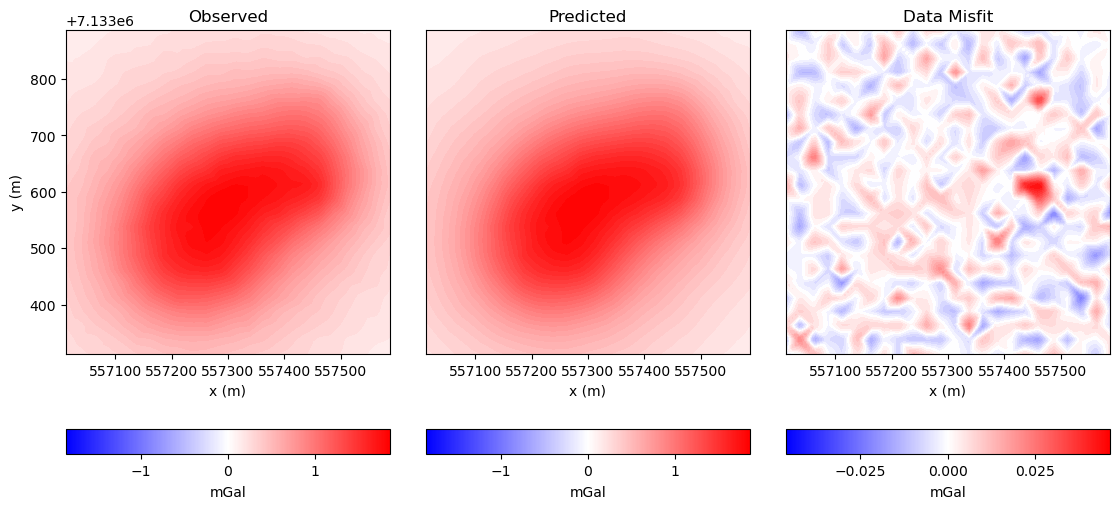

In [34]:
# Predicted data with final recovered model.
dpred = inv_prob_L2.dpred

# Data
dobs = data_grav.dobs
receiver_locations = data_grav.survey.receiver_locations


# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred, dobs - dpred]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["mGal", "mGal", "mGal"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].ax.locator_params(nbins=3)
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

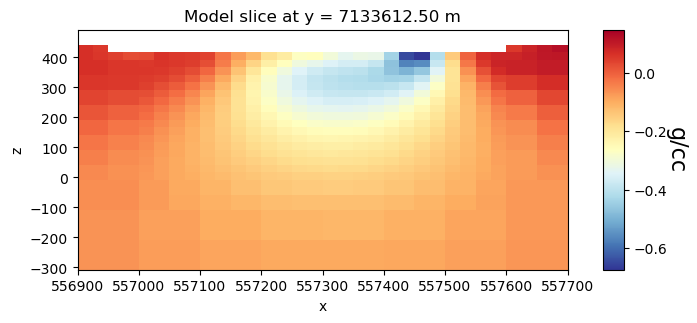

In [49]:
# Plot Recovered Model
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.7, 0.8])

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_model), vmax=np.max(recovered_model)
)
y_idx = int(mesh.shape_cells[1] / 2)
mesh.plot_slice(
    plotting_Map * recovered_model,
    normal="Y",
    ax=ax1,
    ind=y_idx,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title(f"Model slice at y = {mesh.cell_centers_y[y_idx]:.2f} m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label("g/cc", rotation=270, labelpad=15, size=16)

plt.show()